# §6.1 recovery sweep plots

Mechanism check + robustness for the soft causal prior in modified FasterRisk. Loads `results/causal_prior/synthetic/recovery_p30_headline/`.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior.loading import load_recovery_csvs
from src.causal_prior import visualization as viz

ROOT = Path.cwd().parents[2]
recovery = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline')

In [ ]:
# anchor cell = (p=30, n=300, k_star=5, p_edge=0.2); each sweep varies one dim, others fixed
pe_sweep = recovery.query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_sweep  = recovery.query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_sweep  = recovery.query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_sweep  = recovery.query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star

## Anchor cell: $\mu$-sensitivity

One panel, $p_\mathrm{edge}=0.2$. Sanity floor (adversarial collapses to ~0) and invariance check (uniform tracks vanilla) should be visually obvious.

<Axes: title={'center': 'p=30, n=300, k_star=5, p_edge=0.2'}, xlabel='$\\mu_{\\mathrm{relative}}$', ylabel='S precision'>

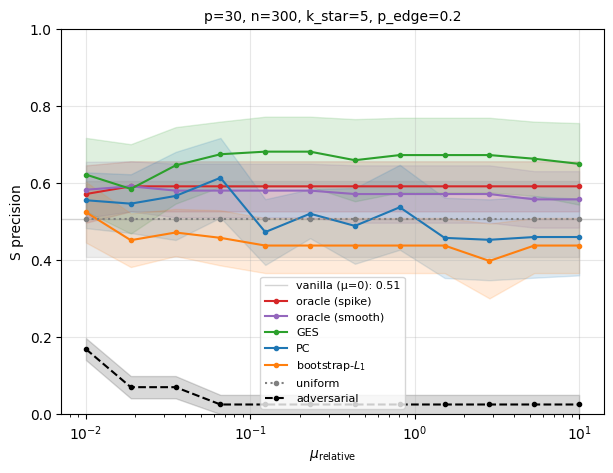

In [3]:
viz.plot_recovery_vs_mu(pe_sweep.query('p_edge == 0.2'))

## $p_\mathrm{edge}$ facet (confounding density)

Higher $p_\mathrm{edge}$ = denser DAG = more confounded correlates competing with $S^*$. Expect gap between causal priors and vanilla to grow with $p_\mathrm{edge}$.

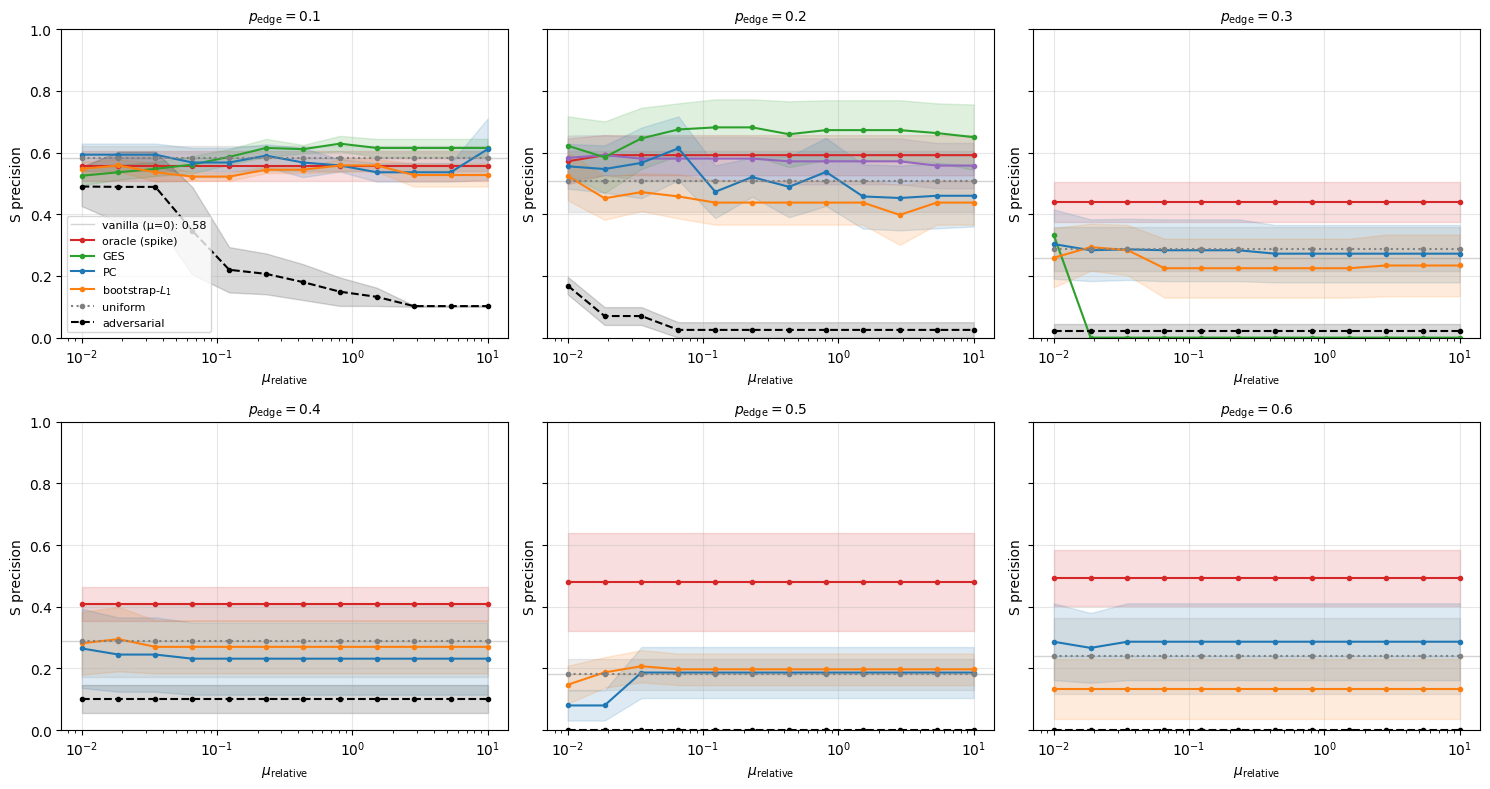

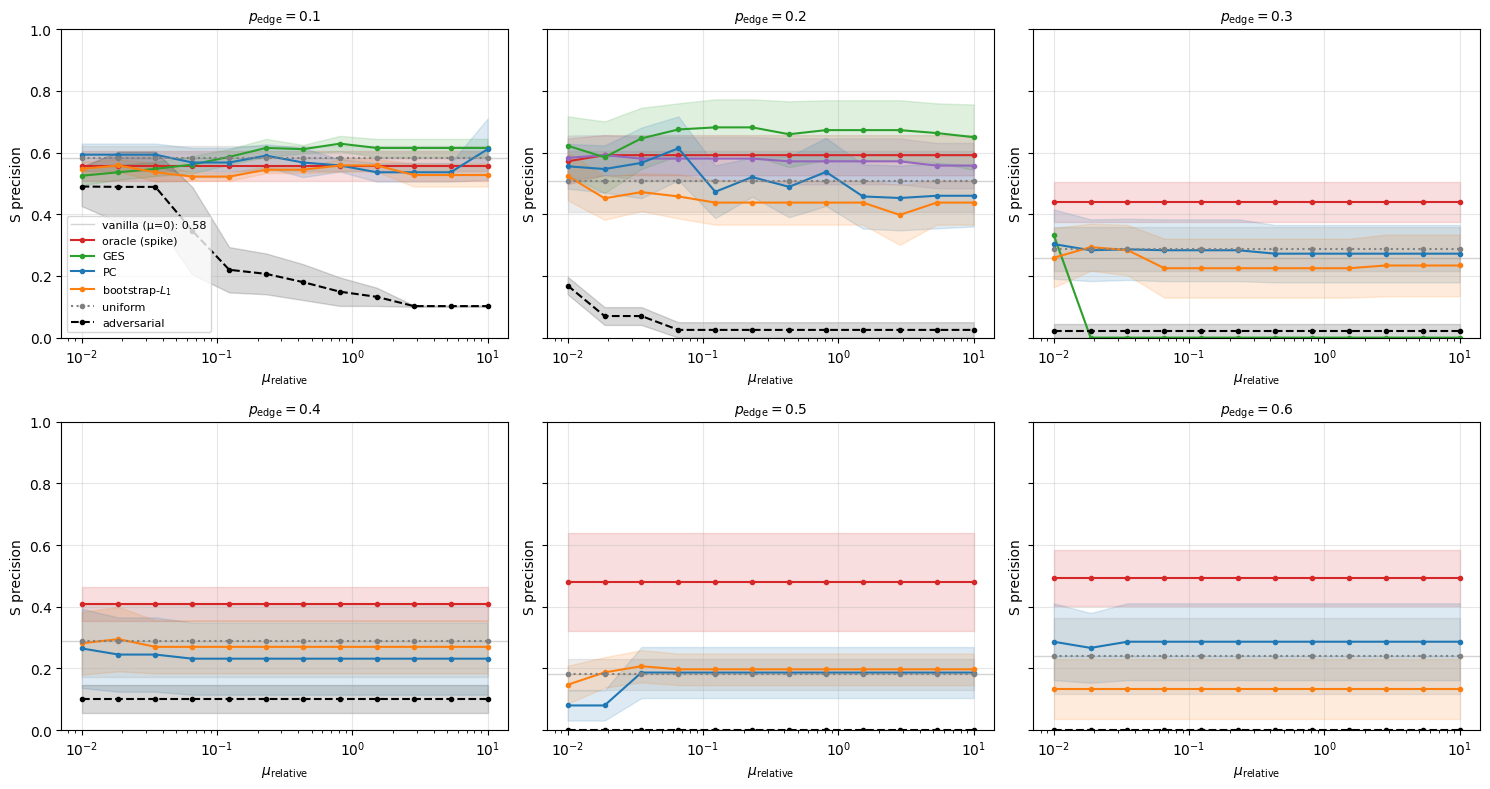

In [4]:
viz.plot_recovery_vs_mu_facet(pe_sweep, facet_col='p_edge', ncols=3)

## Robustness sweeps (precision vs axis at $\mu_\mathrm{rel}=1.0$)

Fix $\mu_\mathrm{rel}=1.0$ (moderate strength; Fig 1A shows precision is stable across $\mu \in [10^{-1}, 10]$). Vanilla baseline (gray squares) is the $\mu=0$ value, which varies with the axis itself. **GES missing at some cells means Phase A timed out** (cubic in $p$; intractable at dense $p\geq 20$ in causal-learn).

### $n$ sweep (sample size)
$n \in \{150, 200, 300, 500, 1000\}$. Expect the prior's gain over vanilla to be largest at small $n$ and shrink at large $n$.

In [ ]:
viz.plot_recovery_vs_axis(n_sweep, axis_col='n')

### $p$ sweep (feature count)
$p \in \{10, 15, 20, 30\}$. Higher $p$ = more candidate features to discriminate among; expect the prior's gain to grow.

In [ ]:
viz.plot_recovery_vs_axis(p_sweep, axis_col='p')

### $k^*$ sweep (target sparsity)
$k^* \in \{3, 5, 7\}$, with $K = 2 k^*$ in FR so the headroom always equals the truth. Sanity check on whether the mechanism scales with target size.

In [ ]:
viz.plot_recovery_vs_axis(k_sweep, axis_col='k_star')

## Soft prior vs hard pre-selection (§6.4)

For each causal/predictive source, soft at $\mu_\mathrm{rel}=1.0$ vs hard pre-selection at $t \in \{0.3, 0.5, 0.7\}$, as a function of $p_\mathrm{edge}$. Soft should at least track the best hard threshold without requiring a threshold-selection rule.

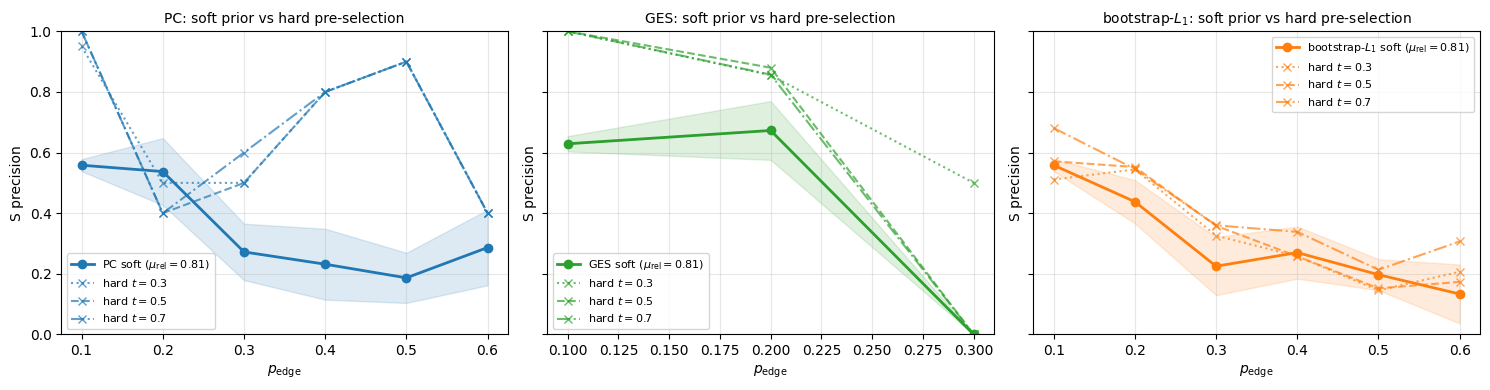

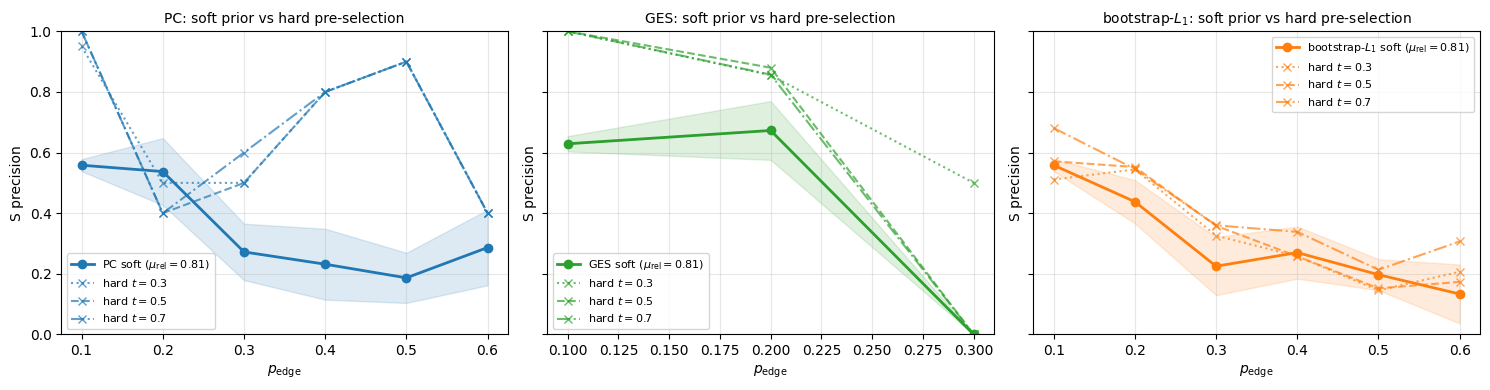

In [8]:
viz.plot_soft_vs_hard_facet(pe_sweep, q_sources=['pc', 'ges', 'bootstrap_l1'], ncols=3)